author: Konrad Basza

# Description of how the source code from the practicalse was adapted

1. Instead of a random starting node, we start from the depot
2. During solution generation, vehicle current capacity is measured, and if it is (nearly) full it returns to depot, where vehicle current capacity is set to zero. So, the solution is one continuous path through all the vertices with some breaks at the depot to reset capacity counter. Comeback to depot can be draw by probability distribution, or can be forced, if no more viable solution can be found
3. `Used number of vehicles` in the solution is calculated from the continuous path, by checking breaks at the depot
4. I experimented with heuristic function
    - inverse distance to the next node is a good heuristics for TSP. For VRP problem, it lacks awareness of the capacity.
    - i added additional heuristics that works like that:
        - when next node's total capacity is high (vehicle is almost full), heuristic would prefer node's slightly closer to the depot. In theory, the cost of the path would be lower, because it wouldn't waste so much time returning from far away, because when vehicle is almost full, it prefers to go in the depot direction. In practise, new heuristc sometimes improved solution by 5%. Othertimes it didn't
    - the final heuristics I selected is calculated using `chosen_heuristics` parameter $\in [0;1]$. When it's 1, the inverse distance heuristics is used, if 0, the new heuristic function. Values $\in (0,1)$ controled how much of which heuristics is used
5. I added logs
    - plotted: Min, Mean, Max vs iterations
    - plotted: Number of used vehicles in the best solution in the iteration vs iterations. Also I added theoretical minimum number of vehicles ($\lfloor \frac{\text{total quantity of requests}}{\text{vehicle capacity}} \rfloor$) that can be used to solve the problem

# Instructions for running it

```
python -m venv venv
source venv/bin/activate

pip install jupyter ipykernel numpy matplotlib tqdm
python -m ipykernel install --user --name=venv
```

And then open `main.ipynb` to run the notebook.

# Code (lower are the solutions)

In [743]:
import math
import functools
import numpy as np
from tqdm import tqdm

# main ACO function
def ant_solver(list_of_nodes, depot_idx, vehicle_capacity, distance, chosen_heuristic, ants=10, max_iter=3000, alpha=1, beta=3, Q=100, rho=0.8, init_pheromone_value=0.01):
    if len(list_of_nodes) == 1:
        raise Exception("Can't do algorithm if there is only one node.")

    logger = {
        "min": [],
        "mean": [],
        "max": [],
        "best_sol_vehicle_used": []
    }

    P = initialize_pheromone(len(list_of_nodes), init_pheromone_value)
    best_sol = None
    best_fit = float('inf')
    for it in tqdm(range(max_iter)):
        sols = list(generate_solutions(list_of_nodes, depot_idx, vehicle_capacity, P, distance, ants, chosen_heuristic, alpha=alpha, beta=beta))
        fits = list(map(lambda x: fitness(list_of_nodes, distance, x), sols))
        P = update_pheromone(P, sols, fits, Q=Q, rho=rho)
        
        local_best_sol = None
        local_best_fit = float('inf')
        for s, f in zip(sols, fits):
            if local_best_sol == None:
                local_best_fit = f
                local_best_sol = s
            if f < local_best_fit:
                local_best_fit = f
                local_best_sol = s

        if local_best_fit < best_fit:
            best_fit = local_best_fit
            best_sol = local_best_sol
        
        logger["min"].append(np.min(fits))
        logger["mean"].append(np.mean(fits))
        logger["max"].append(np.max(fits))
        logger["best_sol_vehicle_used"].append(number_of_vehicles(local_best_sol, depot_idx))

    return best_sol, P, logger

def number_of_vehicles(sol, depot_idx):
    nov = 0
    for e in sol:
        if e == depot_idx:
            nov += 1
    return nov

# compute distance
def distance(r1, r2):
    return math.sqrt((r1["x"] - r2["x"])**2+(r1["y"] - r2["y"])**2)

# compute fitness
def fitness(list_of_nodes, dist, sol):
    sd = 0
    for x, y in zip(sol, sol[1:]):
        sd += dist(list_of_nodes[x], list_of_nodes[y])
    sd += dist(list_of_nodes[sol[-1]], list_of_nodes[sol[0]])
    return sd

# pheromone initizalization
def initialize_pheromone(N, init_pheromone_value):
    return init_pheromone_value*np.ones(shape=(N,N))

# generate solution
def generate_solutions(list_of_nodes, depot_idx, vehicle_capacity, P, dist, N, chosen_heuristic, alpha=1, beta=3):
    
    # probability of selecting and edge (without scaling)
    def compute_prob(i1, i2, ant_capacity):
        dist_val = dist(list_of_nodes[i1], list_of_nodes[i2])
        dist_inv = 1/dist_val if dist_val != 0 else 0
        
        next_node_quantity = 0
        if list_of_nodes[i2]["request"] is not None:
            next_node_quantity = list_of_nodes[i2]["request"]["quantity"]
        #next_node_quantity_normalised = (next_node_quantity) / vehicle_capacity # e [0; 1]
        next_node_fullness = (next_node_quantity + ant_capacity) / vehicle_capacity  # e [0; 1]

        next_node_dist_to_depot = dist(list_of_nodes[i2], list_of_nodes[depot_idx])
        next_node_dist_to_depot_inv = 1/next_node_dist_to_depot if next_node_dist_to_depot != 0 else 0 # closer to depot -> smaller value
        

        nu = chosen_heuristic * dist_inv + (1-chosen_heuristic) * next_node_fullness * next_node_dist_to_depot_inv
        tau = P[i1, i2]
        ret = pow(tau, alpha) * pow(nu,beta)
        return ret if ret > 0.000001 else 0.000001

    V = P.shape[0]
    for i in range(N):
        ant_capacity = 0
        available = list(range(V))
        sol = [depot_idx]
        while len(available) != 1:
            available_within_capacity = list(filter(
                lambda x:
                    ant_capacity + list_of_nodes[x]["request"]["quantity"] <= vehicle_capacity
                    if list_of_nodes[x]["request"] is not None else True,
                available
            ))
            probs = np.array(list(map(lambda x: compute_prob(sol[-1], x, ant_capacity), available_within_capacity)))
            selected = np.random.choice(available_within_capacity, p=probs/sum(probs)) # edge selection
            sol.append(selected)
            if selected != depot_idx:
                available.remove(selected)
                ant_capacity += list_of_nodes[selected]["request"]["quantity"]
            else:
                ant_capacity = 0
        yield sol

def update_pheromone(P, sols, fits, Q=100, rho=0.6):
    ph_update = np.zeros(shape=P.shape)
    for s, f in zip(sols, fits):
        for x, y in zip(s, s[1:]):
            ph_update[x][y] += Q/f
        ph_update[s[-1]][s[0]] += Q/f
    
    return (1-rho)*P + ph_update        

In [744]:
# loading data
import xml.etree.ElementTree as ET

def read_txt_from_file(path):
    f = open(path, 'r')
    data = "\n".join(f.readlines())
    f.close()
    return data

input_xml_data = ["./hw2/data_32.xml", "./hw2/data_72.xml", "./hw2/data_422.xml"]
input_xml_data = list(map(lambda x: {"path": x, "txt": read_txt_from_file(x)},input_xml_data))
input_xml_data = list(map(lambda x:{"xml_root": ET.fromstring(x["txt"]), "path": x["path"]}, input_xml_data))

def extract_from_xml(x):
    network = x["xml_root"].find("network")
    nodes = network.find("nodes")
    x["list_of_nodes"] = nodes.findall("node")
    x["list_of_nodes"] = list(map(lambda x: { "x": float(x.find("cx").text), "y": float(x.find("cy").text), "id": int(x.get("id")), "type": int(x.get("type")), "request": None }, x["list_of_nodes"]))


    number_of_depots = 0
    x["depot_node"] = None
    x["depot_idx"] = -1
    for i in range(len(x["list_of_nodes"])):
        ii = x["list_of_nodes"][i]
        if ii["type"] == 0:
            number_of_depots += 1
            x["depot_node"] = ii
            x["depot_idx"] = i

    if number_of_depots != 1:
        raise Exception("Number of depots must be equal to 1, as it is stated in the description of the task")


    fleet = x["xml_root"].find("fleet")
    list_of_vehicle_profiles = fleet.findall("vehicle_profile")
    if len(list_of_vehicle_profiles) != 1:
        raise Exception("Number of vehicle profiles must be equal to 1, as it is stated in the description of the task")
    
    departute_node = int(list_of_vehicle_profiles[0].find("departure_node").text)
    arrival_node = int(list_of_vehicle_profiles[0].find("arrival_node").text)
    if departute_node != arrival_node:
        raise Exception("Departure node must be equal to arrival node, as state in the description of the task")

    for ii in x["list_of_nodes"]:
        if ii["id"] == departute_node:
            if ii["type"] == 0:
                break
            else:
                raise Exception("Vehicle must go from depot node!")

    x["capacity"] = float(list_of_vehicle_profiles[0].find("capacity").text)
    if x["capacity"] <= 0:
        raise Exception("Capacity must be grater than 0")
    
    requests = x["xml_root"].find("requests")
    x["list_of_requests"] = requests.findall("request")
    x["list_of_requests"] = list(map(lambda x: { "id": int(x.get("id")), "node": int(x.get("node")), "quantity": float(x.find("quantity").text) }, x["list_of_requests"]))

    for ii in x["list_of_requests"]:
        if ii["quantity"] > x["capacity"]:
            raise Exception("Capacity must be grater than single request quantity! Otherwise, the request cannot be processed")

        found = False
        for n in x["list_of_nodes"]:
            if ii["node"] == n["id"]:
                ii["x"] = n["x"]
                ii["y"] = n["y"]
                found = True
                
                if n["request"] is None:
                    n["request"] = ii
                else:
                    raise Exception("Found node that has more than one request.")
                break
        
        if not found:
            raise Exception("Some node was not found for some request")


    return x

input_xml_data = list(map(lambda x:extract_from_xml(x), input_xml_data))

In [745]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import collections as mc

def plot_path(s, P, input_data):
    # plot the pheromone in blue, line width expresses the amount of pheromone on each edge
    lines = []
    colors = []
    for i, v1 in enumerate(input_data["list_of_nodes"]):
        for j, v2 in enumerate(input_data["list_of_nodes"]):
            lines.append([(v1["x"], v1["y"]), (v2["x"], v2["y"])])
            colors.append(P[i][j])

    lc = mc.LineCollection(lines, linewidths=np.array(colors))

    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    ax.add_collection(lc)
    ax.autoscale()

    best_sol = s # save the best solution (for the experiments below)

    sol = best_sol
    print('Fitness: ', fitness(input_data["list_of_nodes"], distance, sol))
    print('Number of vehicles used: ', number_of_vehicles(sol, input_data["depot_idx"]))

    # plot the solution in red
    sol_lines = []
    for i, j in zip(sol, sol[1:]):
        sol_lines.append([(input_data["list_of_nodes"][i]["x"], input_data["list_of_nodes"][i]["y"]), (input_data["list_of_nodes"][j]["x"], input_data["list_of_nodes"][j]["y"])])

    sol_lines.append([(input_data["list_of_nodes"][sol[-1]]["x"], input_data["list_of_nodes"][sol[-1]]["y"]), (input_data["list_of_nodes"][sol[0]]["x"], input_data["list_of_nodes"][sol[0]]["y"])])

    sols_lc = mc.LineCollection(sol_lines, colors='red')
    ax.add_collection(sols_lc)

In [746]:
def plot_logs(logger, minimum_number_of_cars_value):
    x = range(len(logger["min"]))
    
    plt.figure(figsize=(12, 8))
    plt.plot(x, logger["max"], label='max', color='red')
    plt.plot(x, logger["mean"], label='mean', color='green')
    plt.plot(x, logger["min"], label='min', color='blue')
    
    plt.xlabel('iterations')
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.plot(x, logger["best_sol_vehicle_used"], label='number of vehicles used in the best solution')
    plt.axhline(y=minimum_number_of_cars_value, color='r', label='minimum possible number of cars')

    plt.xlabel('iterations')
    plt.legend()
    plt.show()

In [747]:
import math
def minimum_number_of_cars(input_data):
    s = 0
    for i in input_data["list_of_nodes"]:
        s += i["request"]["quantity"] if i["request"] is not None else 0
    return math.ceil(s/input_data["capacity"])

In [748]:
def evaulate_and_display_results(input_data, max_iter=3000, alpha=1, ants=10, beta=3, Q=100, initialize_pheromone=0.01, rho=0.8, chosen_heuristic = 1):
    s, P, logger = ant_solver(
        input_data["list_of_nodes"],
        input_data["depot_idx"],
        input_data["capacity"],
        distance,
        max_iter=max_iter,
        alpha=alpha,
        ants=ants,
        beta=beta,
        Q=Q,
        init_pheromone_value=initialize_pheromone,
        rho=rho,
        chosen_heuristic = chosen_heuristic
    )

    mnoc = minimum_number_of_cars(input_data)
    plot_path(s, P, input_data)
    plot_logs(logger, mnoc)
    

# Results for `data_32.xml`

100%|██████████| 50/50 [00:17<00:00,  2.92it/s]


Fitness:  814.0734903765442
Number of vehicles used:  5


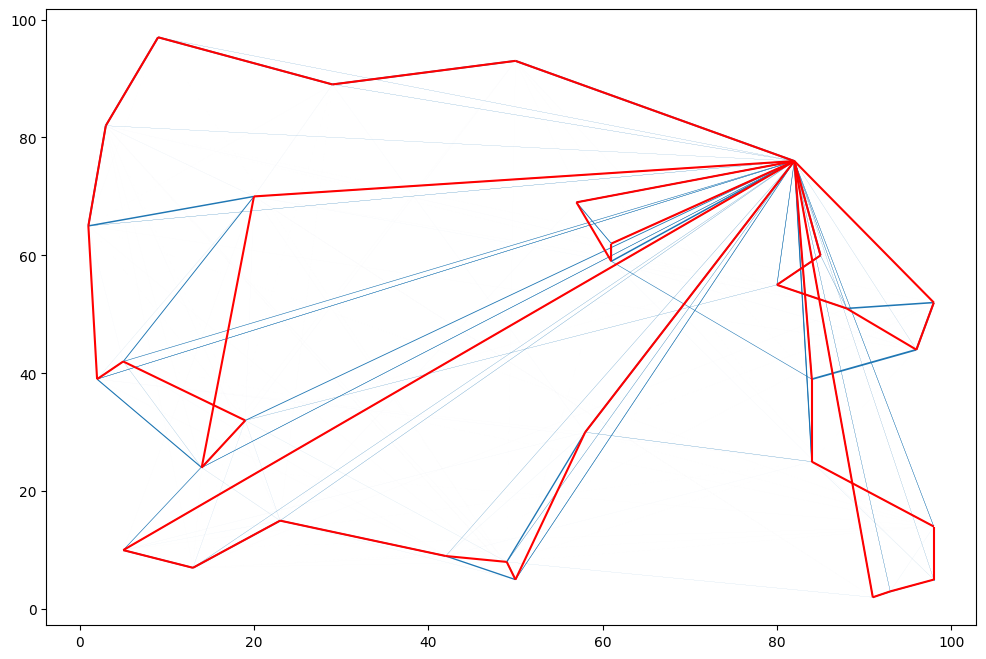

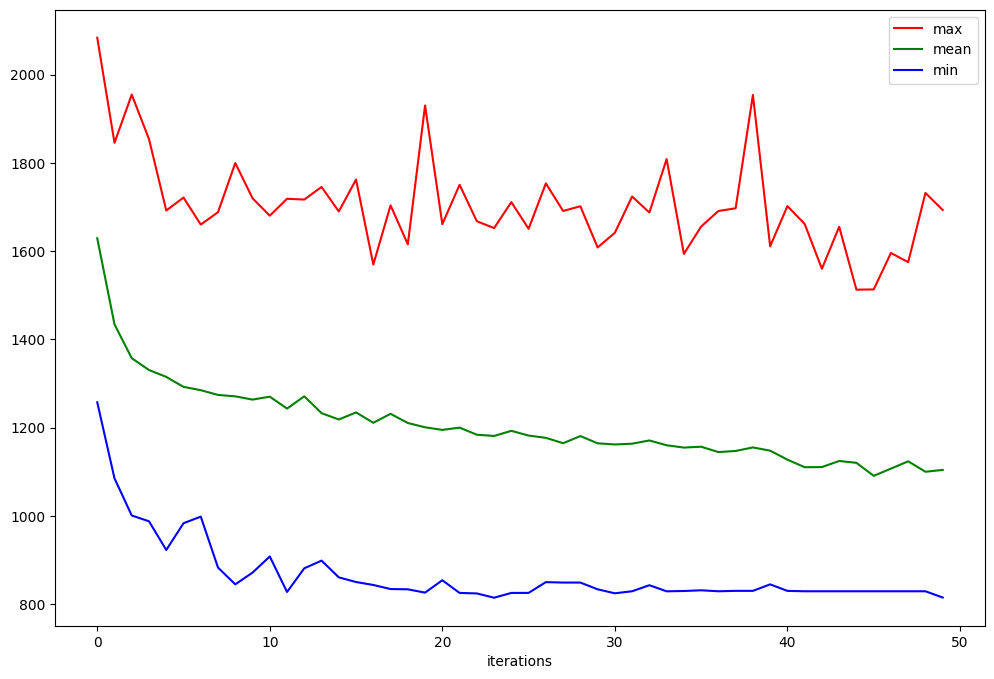

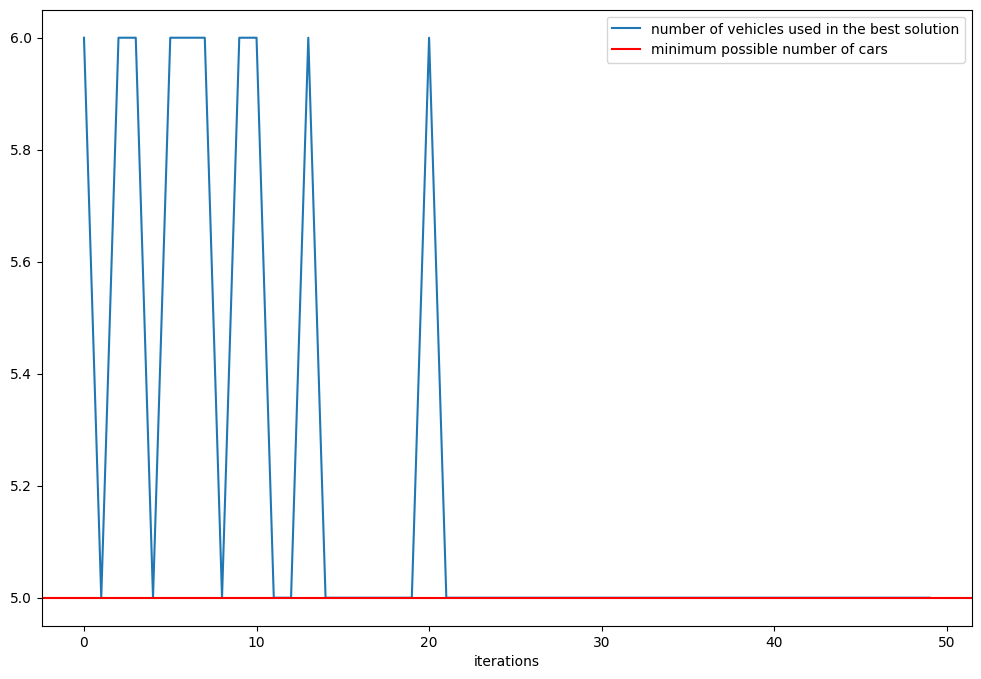

In [ ]:
evaulate_and_display_results(input_xml_data[0],
    max_iter=50,
    alpha=1,
    ants=200,
    beta=1.5,
    Q=4,
    initialize_pheromone=0.01,
    rho=0.55,
    chosen_heuristic = 0.6
)


# Results for `data_72.xml`

100%|██████████| 50/50 [00:57<00:00,  1.15s/it]

Fitness:  283.3349059177312
Number of vehicles used:  5


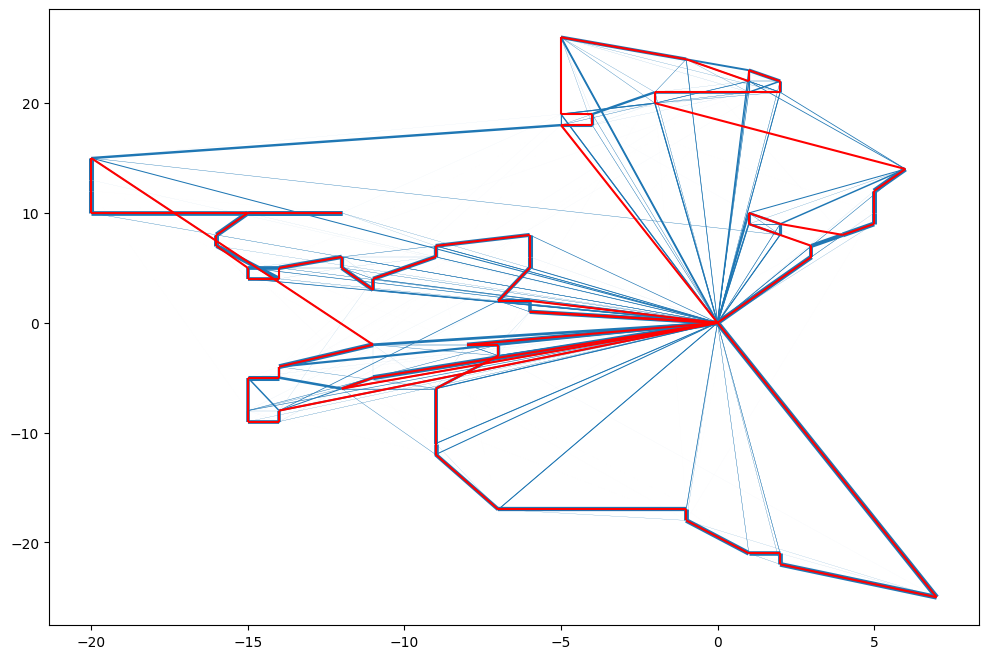

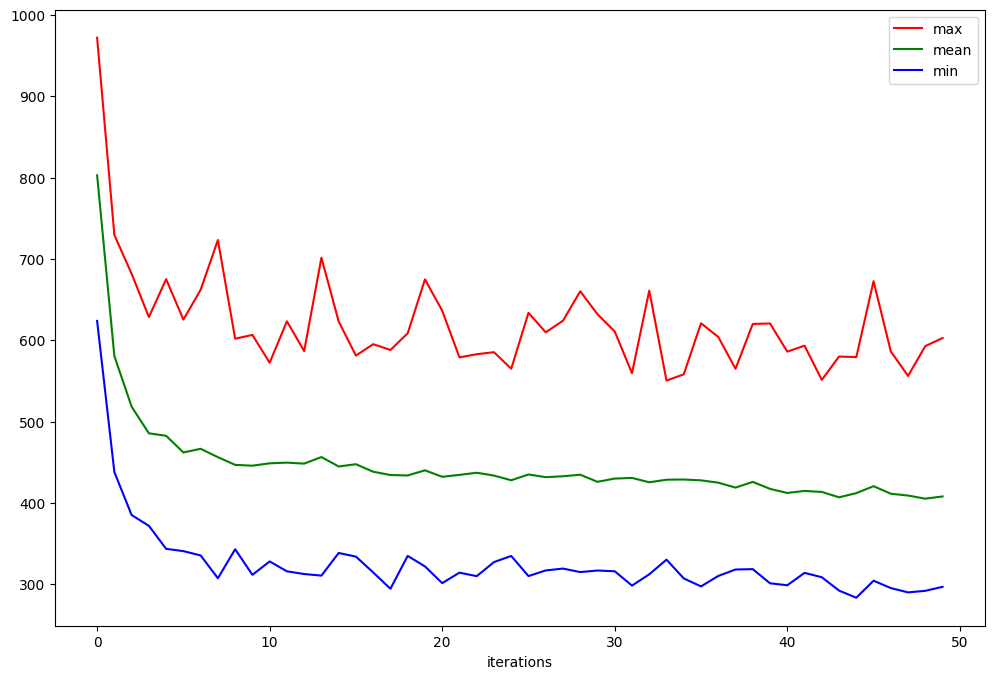

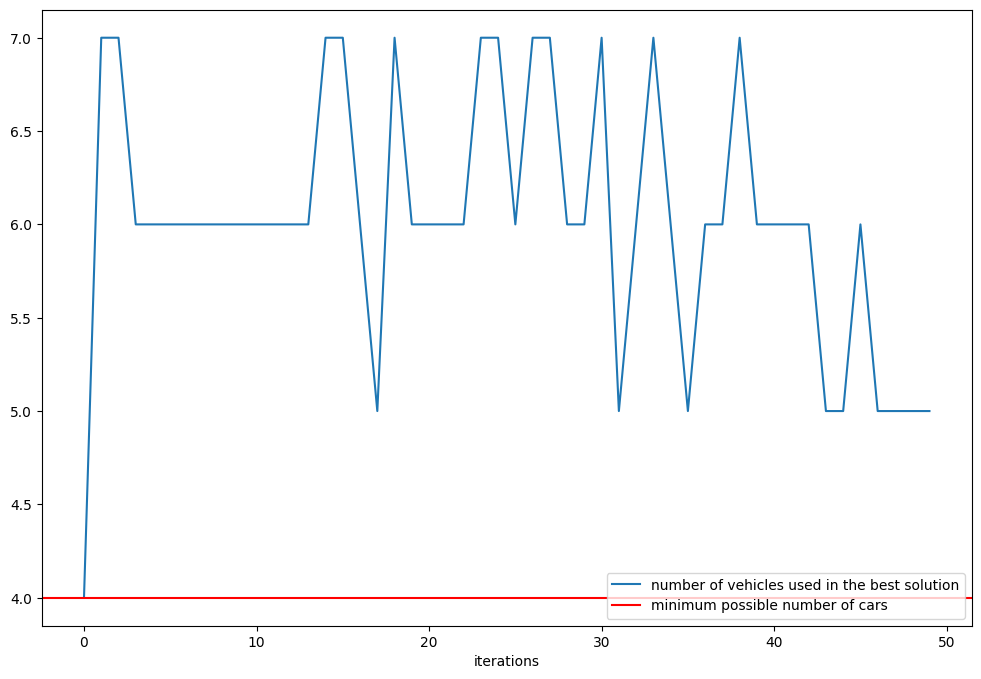

In [755]:

evaulate_and_display_results(input_xml_data[1],
    max_iter=50,
    alpha=1,
    ants=200,
    beta=1.5,
    Q=4,
    initialize_pheromone=0.01,
    rho=0.55,
    chosen_heuristic = 0.6
)

# Results for `data_422.xml`

100%|██████████| 15/15 [07:22<00:00, 29.53s/it]


Fitness:  2853.0787894819923
Number of vehicles used:  60


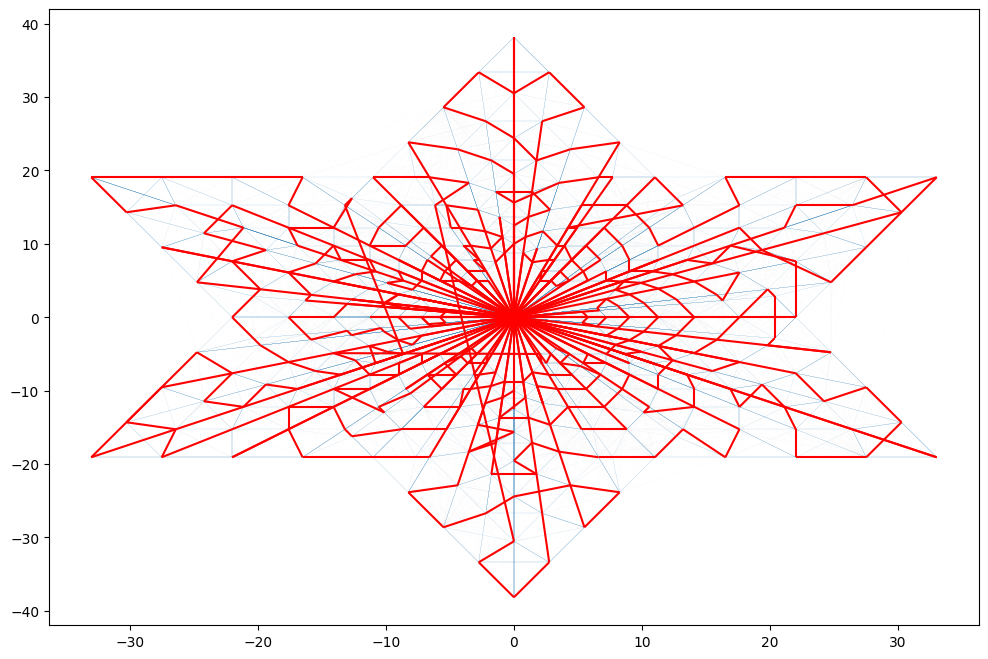

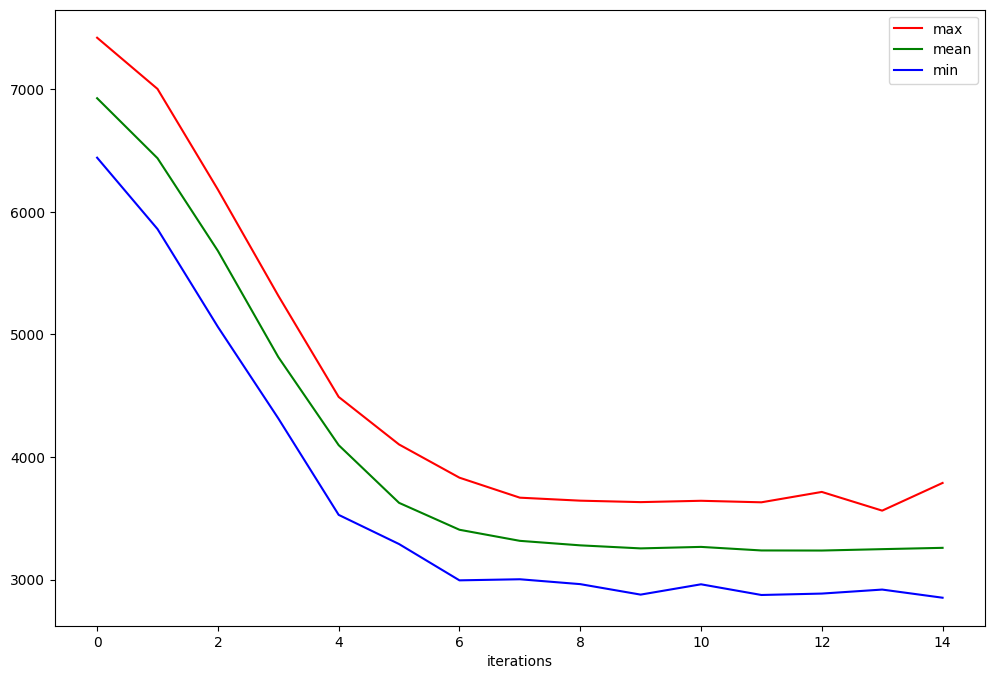

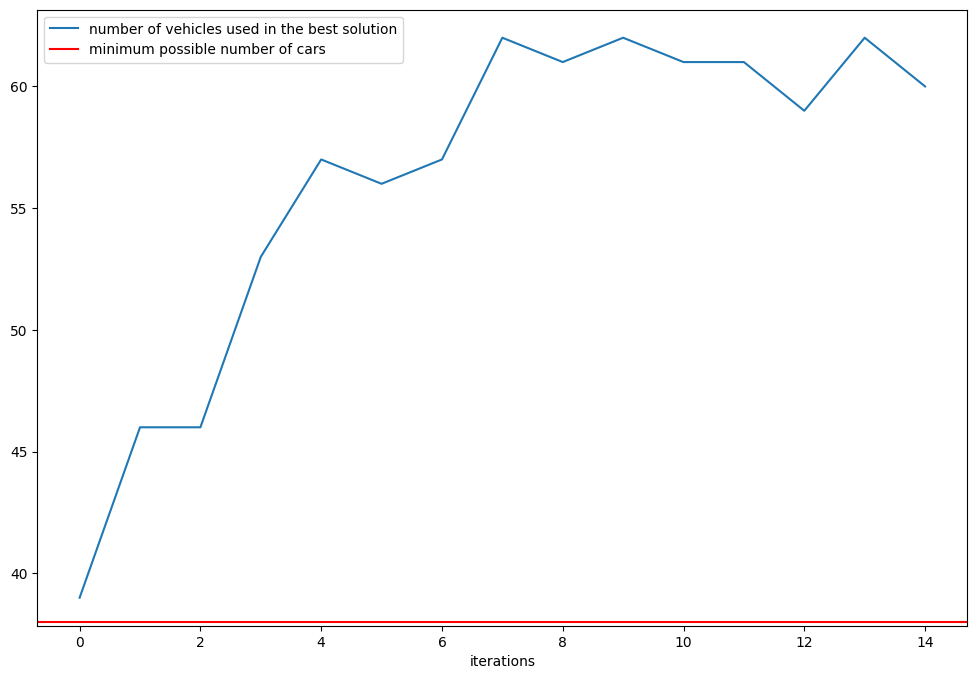

In [757]:

evaulate_and_display_results(input_xml_data[2],
    max_iter=15,
    alpha=1,
    ants=200,
    beta=1.5,
    Q=4,
    initialize_pheromone=0.01,
    rho=0.55,
    chosen_heuristic = 0.6
)